# Fault Tolerance
- Workflow
    - START -> Node1 -> Node2 -> Node3 -> END
- Configure node2 to pause for 30 seconds, allowing us to manually interrupt the workflow at that stage and then resume execution from that point onward. This is to test how LangGraph supports fault tollerance

In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langgraph.checkpoint.memory import MemorySaver


In [2]:
class State(TypedDict):
    input: str
    node1: str
    node2: str
    node3: str

In [3]:
import time

def node1(state: State)-> State:
    print("Node1 done")
    return {
        "node1": "done",
    }

def node2(state: State)->State:
    print("Node2 done")
    time.sleep(30)
    return {
        "node2": "done"
    }

def node3(state: State)->State:
    print("Node3 done")
    return {
        "node3": "done"
    }

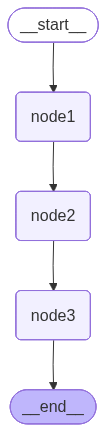

In [4]:
graph = StateGraph(State)

# Adding Nodes
graph.add_node("node1", node1)
graph.add_node("node2", node2)
graph.add_node("node3", node3)

# Adding edges
graph.add_edge(START, "node1")
graph.add_edge("node1", "node2")
graph.add_edge("node2", "node3")
graph.add_edge("node3", END)

# Defining checkpointer
checkpointer = MemorySaver()

# Workflow
workflow = graph.compile(checkpointer = checkpointer)
workflow

In [5]:
# Defining the thread_id
thread_id = 1
config = {
            "configurable":{
                "thread_id": thread_id
            }
        }

initial_state = {"input": "Start"}
workflow.invoke(initial_state,config=config)

Node1 done
Node2 done


KeyboardInterrupt: 

- Now I have interupted the workflow while the node2 was being executed
- This is to test fault tollerance

In [6]:
workflow.get_state(config=config)

StateSnapshot(values={'input': 'Start', 'node1': 'done'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3939-6c1a-8001-0a8f8f022ed0'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-05T15:59:44.082018+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3938-623e-8000-ed5ec4c28d56'}}, tasks=(PregelTask(id='99fee93c-6cc3-5d4f-3264-67f511dcc7ab', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

- It shows that the next node to be executed is node2

In [7]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'Start', 'node1': 'done'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3939-6c1a-8001-0a8f8f022ed0'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-05T15:59:44.082018+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3938-623e-8000-ed5ec4c28d56'}}, tasks=(PregelTask(id='99fee93c-6cc3-5d4f-3264-67f511dcc7ab', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'Start'}, next=('node1',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3938-623e-8000-ed5ec4c28d56'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-05T15:59:44.081354+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3936-652

- It has the state stored till node1
- To resume from Node2, or from where it crashed just dont pass initial_state instead pass None in the invoke function

In [9]:
workflow.invoke(None, config=config)

Node2 done
Node3 done


{'input': 'Start', 'node1': 'done', 'node2': 'done', 'node3': 'done'}

- Now we can see that the execution is starting from Node2 and not from Node1

# Running from a particular checkpoint
- Get the checkpoint_id from where you want to begin the execution by running `get_state_history()`
- Then run `workflow.invoke()` by passing checkpoint_id in the config and None as the initial state

In [11]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'Start', 'node1': 'done', 'node2': 'done', 'node3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118aca-d975-6116-8003-d682ec562583'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-05T16:02:15.101254+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118aca-d973-6b7c-8002-97c807cdea4c'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'input': 'Start', 'node1': 'done', 'node2': 'done'}, next=('node3',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118aca-d973-6b7c-8002-97c807cdea4c'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-03-05T16:02:15.100686+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3939-6c1a-8001-0a8f8f022ed0'}}, tasks=(PregelTask(id='df3d5b0e-f73a-b166-ce7c-ef9a6c5e1978', name='no

In [13]:
workflow.invoke(
    None, 
    config = {
        "configurable":{
            "thread_id":"1", 
            "checkpoint_id":"1f118ac5-3938-623e-8000-ed5ec4c28d56"
            }
        }
    )

Node1 done
Node2 done
Node3 done


{'input': 'Start', 'node1': 'done', 'node2': 'done', 'node3': 'done'}

- Since I used the checkpoint of node1 the execution starts from node1

# Updating the state at a particular checkpoint

In [16]:
workflow.update_state(
    {
        "configurable":{
            "thread_id":"1", 
            "checkpoint_id":"1f118ac5-3939-6c1a-8001-0a8f8f022ed0",
            "checkpoint_ns": ""
            }
    },
    {
        "node1": "reupdated_node1"}
    
)

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f118bab-2500-6e74-8002-8ee796b97ae4'}}

In [17]:
list(workflow.get_state_history(config=config))

[StateSnapshot(values={'input': 'Start', 'node1': 'reupdated_node1'}, next=('node2',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118bab-2500-6e74-8002-8ee796b97ae4'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2026-03-05T17:42:35.977060+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118ac5-3939-6c1a-8001-0a8f8f022ed0'}}, tasks=(PregelTask(id='71b182e8-af74-e2c5-bc6d-2ceb1d1e64d6', name='node2', path=('__pregel_pull', 'node2'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'input': 'Start', 'node1': 'done', 'node2': 'done', 'node3': 'done'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f118b9a-a9fa-6ed8-8003-d267a38d0b69'}}, metadata={'source': 'loop', 'step': 3, 'parents': {}}, created_at='2026-03-05T17:35:13.580385+00:00', parent_config={'configurable': {'thread_id': '1', 

- Now you can see that a new state is added i.e. node1 = reupdated_node1